In [7]:
import os
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt


In [8]:
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [10]:
DATA_ROOT = r"D:\Datasets\Phase1_224x224_RGB"
MODEL_SAVE_PATH = r"D:\MinorProject\MinorProject6thSem\models\best_hybrid_effnet_vit_rgb_phase1.pth"


BATCH_SIZE = 8
NUM_EPOCHS = 15
LR = 1e-4

In [11]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [12]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [13]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "val"), transform=test_transform)
test_seen_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "test_seen"), transform=test_transform)
test_unseen_dataset = datasets.ImageFolder(os.path.join(DATA_ROOT, "test_unseen"), transform=test_transform)

In [14]:
print("Class mapping:", train_dataset.class_to_idx)

Class mapping: {'fake': 0, 'real': 1}


In [15]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_seen_loader = DataLoader(test_seen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_unseen_loader = DataLoader(test_unseen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

In [16]:
# ===============================
# HYBRID MODEL (EfficientNet-B0 + ViT-B/16)
# ===============================

class HybridModel(nn.Module):
    def __init__(self):
        super(HybridModel, self).__init__()

        self.cnn = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )
        self.cnn.classifier = nn.Identity()

        self.vit = models.vit_b_16(
            weights=models.ViT_B_16_Weights.DEFAULT
        )
        self.vit.heads.head = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Linear(1280 + 768, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        cnn_feat = self.cnn(x)
        vit_feat = self.vit(x)
        combined = torch.cat((cnn_feat, vit_feat), dim=1)
        output = self.classifier(combined)
        return output

model = HybridModel().to(DEVICE)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-3dd342df.pth" to C:\Users\harsh/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-3dd342df.pth
100%|██████████| 20.5M/20.5M [00:02<00:00, 10.7MB/s]


In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

def evaluate(model, loader, return_preds=False, return_probs=False):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            if return_preds:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            if return_probs:
                all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total

    if return_preds and return_probs:
        return avg_loss, accuracy, all_preds, all_labels, all_probs
    if return_preds:
        return avg_loss, accuracy, all_preds, all_labels
    return avg_loss, accuracy


In [18]:
# ===============================
# TRAINING LOOP
# ===============================

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += (preds == labels).sum().item()
        total += labels.size(0)

    scheduler.step()

    train_loss = running_loss / total
    train_acc = running_corrects / total
    val_loss, val_acc = evaluate(model, val_loader)

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())


Epoch [1/15]
Train Loss: 0.0356 | Train Acc: 0.9890
Val Loss:   0.0005 | Val Acc:   1.0000

Epoch [2/15]
Train Loss: 0.0226 | Train Acc: 0.9941
Val Loss:   0.0007 | Val Acc:   1.0000

Epoch [3/15]
Train Loss: 0.0104 | Train Acc: 0.9968
Val Loss:   0.0003 | Val Acc:   1.0000

Epoch [4/15]
Train Loss: 0.0050 | Train Acc: 0.9985
Val Loss:   0.0002 | Val Acc:   1.0000

Epoch [5/15]
Train Loss: 0.0041 | Train Acc: 0.9988
Val Loss:   0.0006 | Val Acc:   1.0000

Epoch [6/15]
Train Loss: 0.0005 | Train Acc: 0.9999
Val Loss:   0.0001 | Val Acc:   1.0000

Epoch [7/15]
Train Loss: 0.0011 | Train Acc: 0.9996
Val Loss:   0.0001 | Val Acc:   1.0000

Epoch [8/15]
Train Loss: 0.0009 | Train Acc: 0.9998
Val Loss:   0.0003 | Val Acc:   1.0000

Epoch [9/15]
Train Loss: 0.0010 | Train Acc: 0.9996
Val Loss:   0.0008 | Val Acc:   1.0000

Epoch [10/15]
Train Loss: 0.0003 | Train Acc: 0.9999
Val Loss:   0.0001 | Val Acc:   1.0000

Epoch [11/15]
Train Loss: 0.0002 | Train Acc: 0.9999
Val Loss:   0.0001 | Val 

In [19]:
model.load_state_dict(best_model_wts)
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print("\nBest model saved locally.")


Best model saved locally.


In [20]:
# ===============================
# FINAL EVALUATION
# ===============================

train_loss, train_acc = evaluate(model, train_loader)
val_loss, val_acc = evaluate(model, val_loader)

test_seen_loss, test_seen_acc, seen_preds, seen_labels = evaluate(
    model, test_seen_loader, return_preds=True
)

test_unseen_loss, test_unseen_acc, unseen_preds, unseen_labels, unseen_probs = evaluate(
    model, test_unseen_loader, return_preds=True, return_probs=True
)

In [21]:
fpr, tpr, thresholds = roc_curve(unseen_labels, unseen_probs)
roc_auc = auc(fpr, tpr)

In [21]:
print("\n===== FINAL RESULTS =====")
print(f"Train Loss:       {train_loss:.4f} | Train Acc:       {train_acc:.4f}")
print(f"Validation Loss:  {val_loss:.4f} | Validation Acc:  {val_acc:.4f}")
print(f"Test Seen Loss:   {test_seen_loss:.4f} | Test Seen Acc:   {test_seen_acc:.4f}")
print(f"Test Unseen Loss: {test_unseen_loss:.4f} | Test Unseen Acc: {test_unseen_acc:.4f}")
print(f"Test Unseen AUC:  {roc_auc:.4f}")

In [22]:
print("\nConfusion Matrix - Test Seen")
print(confusion_matrix(seen_labels, seen_preds))
print(classification_report(seen_labels, seen_preds))


Confusion Matrix - Test Seen
[[500   0]
 [  0 500]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       500
           1       1.00      1.00      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [23]:
print("\nConfusion Matrix - Test Unseen")
print(confusion_matrix(unseen_labels, unseen_preds))
print(classification_report(unseen_labels, unseen_preds))


Confusion Matrix - Test Unseen
[[296 704]
 [  0 500]]
              precision    recall  f1-score   support

           0       1.00      0.30      0.46      1000
           1       0.42      1.00      0.59       500

    accuracy                           0.53      1500
   macro avg       0.71      0.65      0.52      1500
weighted avg       0.81      0.53      0.50      1500



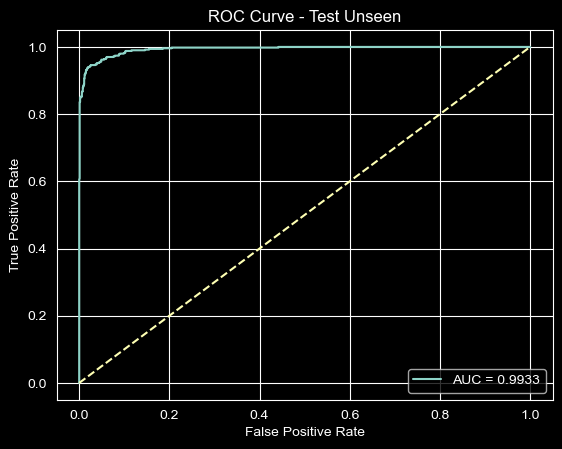

In [24]:
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Unseen")
plt.legend()
plt.show()